In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sleep_health_and_lifestyle_dataset[1].csv to Sleep_health_and_lifestyle_dataset[1].csv


In [4]:
import pandas as pd
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset[1].csv')

In [5]:
%%capture
!pip install scikit-learn-extra

In [3]:

!pip install "numpy<2" --quiet

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn_extra.cluster import KMedoids

df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset[1].csv')

processing_df = df.copy()
if 'Person ID' in processing_df.columns:
    processing_df = processing_df.drop('Person ID', axis=1)

le = LabelEncoder()
cat_cols = processing_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    processing_df[col] = le.fit_transform(processing_df[col].astype(str))

scaler = StandardScaler()
scaled_data = scaler.fit_transform(processing_df)

print("NumPy version:", np.__version__)
print("Preprocessed data shape:", scaled_data.shape)

NumPy version: 1.26.4
Preprocessed data shape: (374, 12)


In [5]:
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(scaled_data)

df['Cluster'] = kmedoids.labels_

print("Cluster centers (medoids indices):", kmedoids.medoid_indices_)
display(df.groupby('Cluster').mean(numeric_only=True))

Cluster centers (medoids indices): [151 152 153]


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Cluster,,,,,,,,
0,187.682796,42.201613,7.13172,7.30914,59.166667,5.387097,70.177419,6810.483871
1,153.000000,39.000000,7.20000,8.00000,60.000000,5.000000,68.000000,8000.000000
2,154.000000,39.000000,7.20000,8.00000,60.000000,5.000000,68.000000,8000.000000


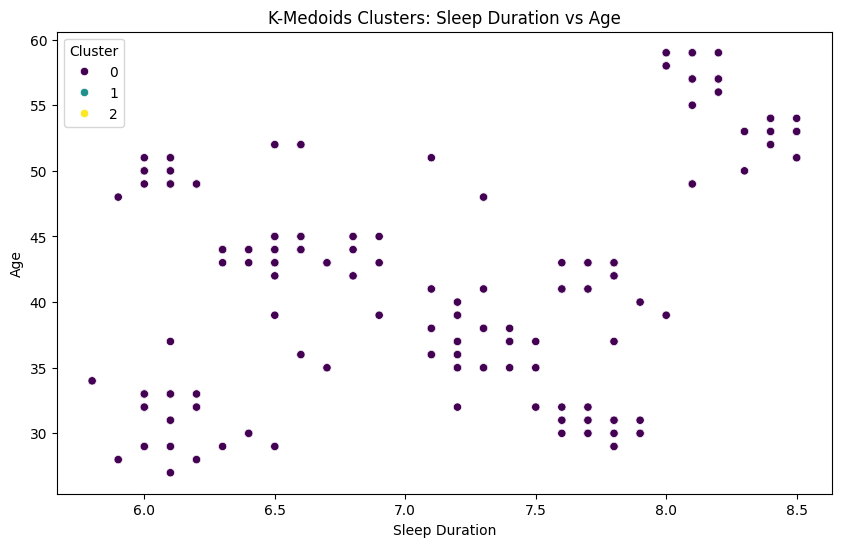

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sleep Duration', y='Age', hue='Cluster', palette='viridis')
plt.title('K-Medoids Clusters: Sleep Duration vs Age')
plt.show()

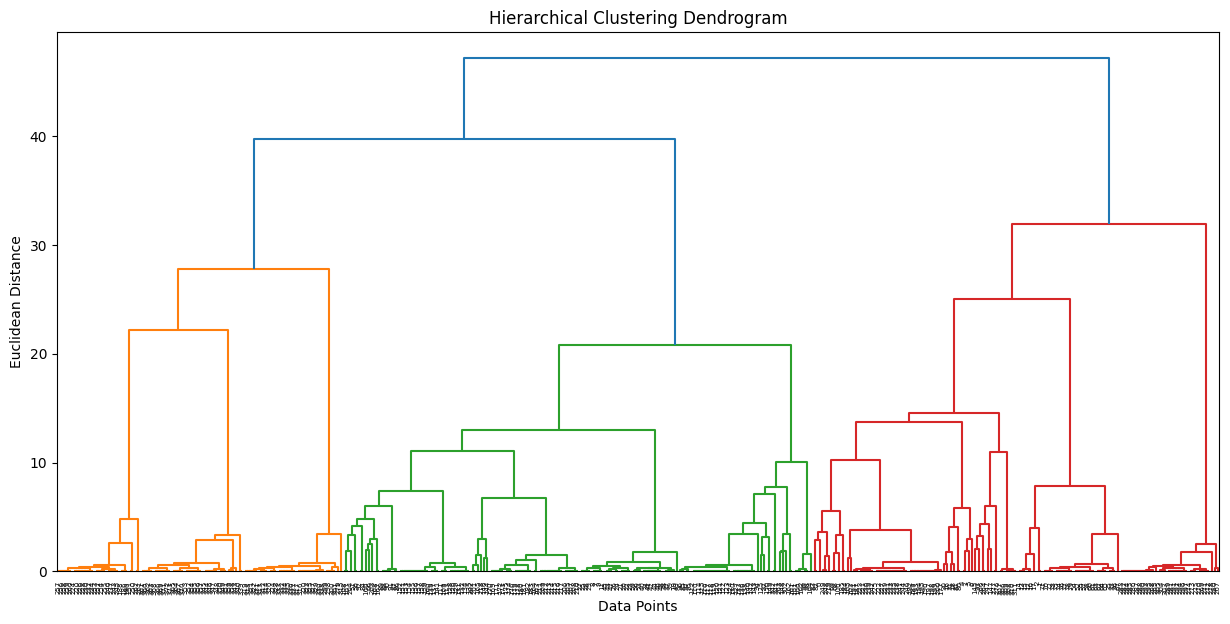

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the linkage matrix
linked_data = linkage(scaled_data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()


Hierarchical Cluster distribution:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Cluster
Hierarchical_Cluster,,,,,,,,,
0,172.900763,40.763359,6.287023,6.015267,52.770992,7.351145,74.312977,6567.175573,0.000000
1,310.565217,52.195652,7.769565,8.413043,50.217391,3.358696,66.163043,5967.391304,0.000000
2,125.185430,37.317881,7.476821,7.768212,70.178808,4.913907,69.006623,7550.993377,0.019868


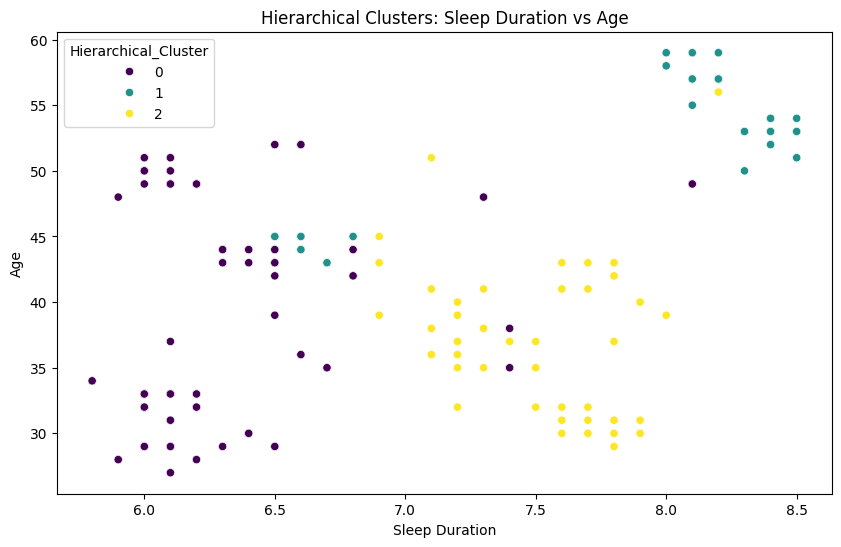

In [9]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(scaled_data)

print("Hierarchical Cluster distribution:")
display(df.groupby('Hierarchical_Cluster').mean(numeric_only=True))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sleep Duration', y='Age', hue='Hierarchical_Cluster', palette='viridis')
plt.title('Hierarchical Clusters: Sleep Duration vs Age')
plt.show()

DBSCAN Cluster distribution (Note: -1 represents noise points):


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Cluster,Hierarchical_Cluster
DBSCAN_Cluster,,,,,,,,,,
-1,159.050000,39.912500,7.025000,6.975,56.6875,5.575,73.312500,6206.25,0.000000,0.925
0,33.612903,30.483871,7.738710,7.000,75.0000,6.000,70.000000,8000.00,0.000000,2.000
1,13.800000,29.000000,6.040000,6.000,30.0000,8.000,70.000000,8000.00,0.000000,0.000
2,63.500000,32.291667,6.062500,6.000,30.0000,8.000,72.000000,5000.00,0.000000,0.000
3,120.720000,37.120000,7.160000,8.000,60.0000,4.000,68.000000,7000.00,0.000000,2.000
4,89.500000,35.000000,7.266667,8.000,60.0000,4.000,65.000000,5000.00,0.000000,2.000
5,101.000000,36.000000,7.160000,8.000,60.0000,4.000,68.000000,7000.00,0.000000,2.000
6,141.000000,38.304348,7.243478,8.000,60.0000,5.000,68.000000,8000.00,0.130435,2.000
7,191.793103,42.034483,7.751724,8.000,90.0000,5.000,69.862069,8000.00,0.000000,2.000


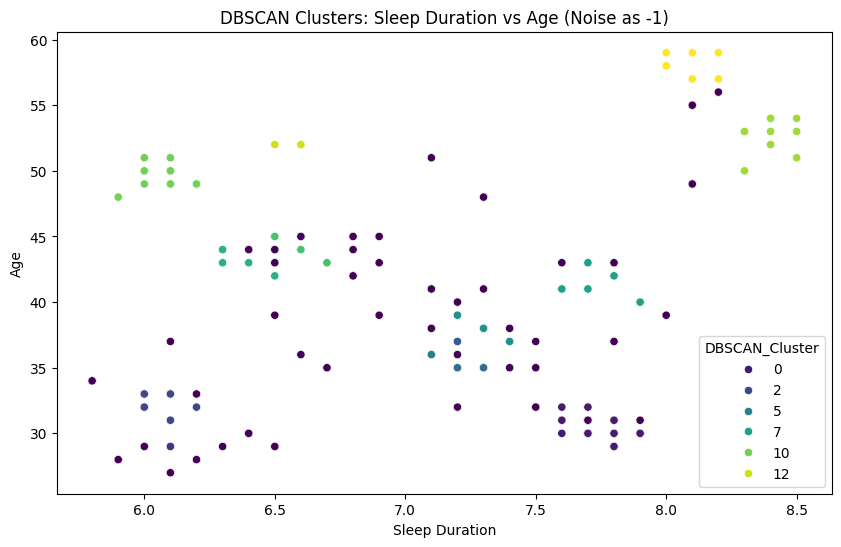

In [10]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

dbsc = DBSCAN(eps=0.8, min_samples=5)
df['DBSCAN_Cluster'] = dbsc.fit_predict(scaled_data)

print("DBSCAN Cluster distribution (Note: -1 represents noise points):")
display(df.groupby('DBSCAN_Cluster').mean(numeric_only=True))
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sleep Duration', y='Age', hue='DBSCAN_Cluster', palette='viridis')
plt.title('DBSCAN Clusters: Sleep Duration vs Age (Noise as -1)')
plt.show()